# Figure S11: Age-effect heatmap across all 33 microstructural metrics

Replicates the Figure S10 heatmap structure using pooled harmonized age-effect values, with Figure 4-style age-effect colorbar.


In [12]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(arrow)
  library(viridis)
  library(grid)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s11_dir <- fs::path(project_root, "figures", "Supplement", "FigureS11")
fs::dir_create(figure_s11_dir, recurse = TRUE)

age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
if (!file.exists(age_effect_file)) {
  stop("Missing assembled age-effect file: ", age_effect_file)
}

df_age_all <- readRDS(age_effect_file)
if (!is.data.frame(df_age_all)) stop("Age effects object is not a data.frame: ", age_effect_file)

required_cols <- c("source", "output_type", "scanner_manufacturer", "qc_metric", "metric", "bundle", "bundle_category", "age_effect_size")
missing_cols <- setdiff(required_cols, names(df_age_all))
if (length(missing_cols) > 0) {
  stop("Age effects file missing required columns: ", paste(missing_cols, collapse = ", "))
}

qc_target <- "no_quality"
source_target <- "harmonized"
output_target <- "pooled"
scanner_target <- "all"
metrics_keep <- config$microstructural_metrics
if (length(metrics_keep) != 33) {
  message("[FigureS11] config$microstructural_metrics has ", length(metrics_keep), " metrics (expected 33). Continuing with config-defined list.")
}



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS11/S11_age_effect_heatmap_all_microstructure.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS11/S11_age_effect_heatmap_all_microstructure.png



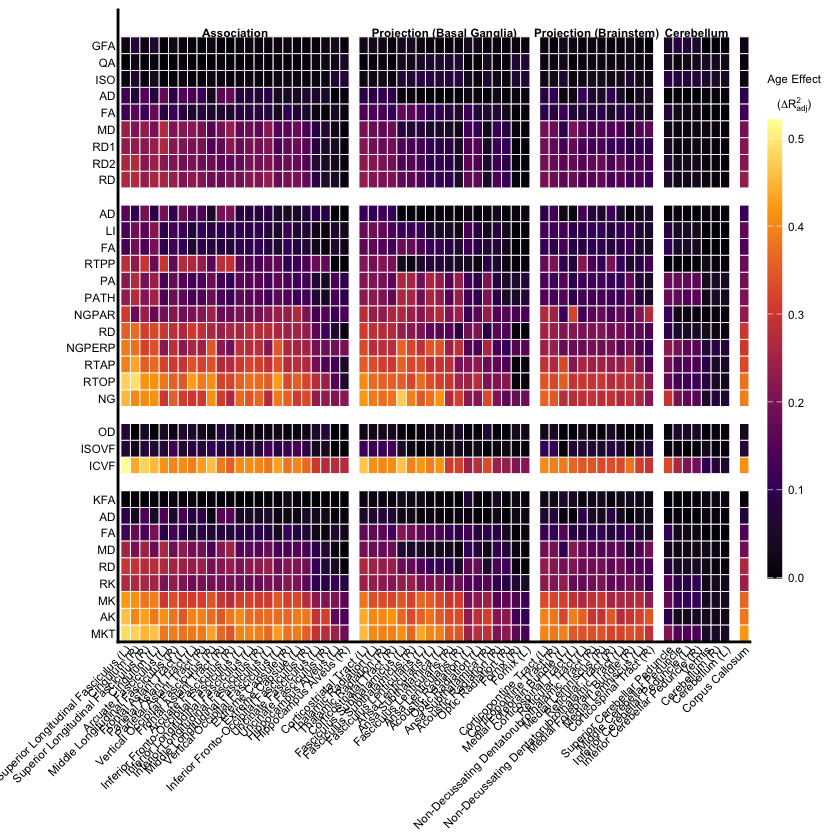

In [ ]:
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")
category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Commissure"
)

metric_display <- setNames(
  ifelse(
    str_detect(metrics_keep, "_"),
    str_to_upper(str_remove(metrics_keep, "^[^_]+_")),
    str_to_upper(metrics_keep)
  ),
  metrics_keep
)

df_heat <- df_age_all %>%
  filter(
    source == source_target,
    output_type == output_target,
    scanner_manufacturer == scanner_target,
    qc_metric == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle), !is.na(bundle_category), !is.na(age_effect_size)
  ) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    bundle_clean = bundle,
    bundle_category = case_when(
      bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
      bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
      TRUE ~ bundle_category
    ),
    bundle_clean = bundle_clean %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  ) %>%
  filter(software %in% software_order)

if (nrow(df_heat) == 0) stop("No rows for FigureS11 heatmap after filtering.")

metric_rank <- df_heat %>%
  group_by(software, metric) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(software = factor(software, levels = software_order)) %>%
  arrange(software, desc(mean_effect), metric)

metric_levels <- c()
for (sw in software_order) {
  sw_metrics <- metric_rank %>% filter(software == sw) %>% pull(metric)
  if (length(sw_metrics) > 0) {
    metric_levels <- c(metric_levels, sw_metrics, paste0("spacer_", sw))
  }
}
metric_levels <- metric_levels[!grepl("^spacer_DSI Studio$", metric_levels)]

bundle_rank <- df_heat %>%
  group_by(bundle_category, bundle_clean) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category = factor(bundle_category, levels = category_order)) %>%
  arrange(bundle_category, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order) {
  cat_bundles <- bundle_rank %>% filter(bundle_category == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Commissure$", bundle_levels)]

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_rank %>%
  group_by(bundle_category) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category != "Commissure")

spacer_rows <- expand.grid(
  bundle_clean = bundle_levels,
  metric = metric_levels[grepl("^spacer_", metric_levels)],
  stringsAsFactors = FALSE
) %>%
  mutate(age_effect_size = NA_real_)

spacer_cols <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric = metric_levels,
  stringsAsFactors = FALSE
) %>%
  mutate(age_effect_size = NA_real_)

df_plot <- bind_rows(
  df_heat %>% select(bundle_clean, metric, age_effect_size),
  spacer_rows,
  spacer_cols
) %>%
  distinct(bundle_clean, metric, .keep_all = TRUE) %>%
  mutate(
    bundle_clean = factor(bundle_clean, levels = bundle_levels),
    metric = factor(metric, levels = metric_levels)
  )

x_labels <- levels(df_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""

y_levels <- levels(df_plot$metric)
y_labels <- ifelse(
  grepl("^spacer_", y_levels),
  "",
  unname(metric_display[y_levels])
)
y_labels[is.na(y_labels)] <- y_levels[is.na(y_labels)]

p_s11 <- ggplot(df_plot, aes(x = bundle_clean, y = metric, fill = age_effect_size)) +
  geom_tile(color = "white", linewidth = 0.25) +
  scale_fill_viridis_c(
    option = "inferno",
    na.value = "white",
    name = expression(atop("Age Effect", "(" * Delta * R[adj]^2 * ")"))
  ) +
  guides(fill = guide_colorbar(
    barheight = grid::unit(length(metric_levels[!grepl("^spacer_", metric_levels)]) * 0.58, "lines"),
    barwidth = grid::unit(0.62, "lines")
  )) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = c(0.8, 0.6))) +
  scale_y_discrete(labels = y_labels, expand = expansion(mult = c(0, 0.06))) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL, title = NULL) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 7,
    axis_text_pt = 7,
    legend_title_pt = 9,
    legend_text_pt = 9,
    base_size_pt = 7
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.margin = margin(t = 6, r = 8, b = 6, l = 40)
  )

y_top <- length(metric_levels) + 0.75
for (i in seq_len(nrow(cat_positions))) {
  p_s11 <- p_s11 + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category[i],
    family = font_family_use,
    size = 7 / .pt,
    fontface = "bold"
  )
}

p_s11

save_plot_outputs(
  plot_obj = p_s11,
  stub = "S11_age_effect_heatmap_all_microstructure",
  out_dir = figure_s11_dir,
  width_in = 13,
  height_in = 11
)
